# Exploratory Data Analysis (EDA) & Data Cleaning
Notebook ini berfungsi untuk membersihkan data mentah dari GitHub dan melakukan EDA awal.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Load Data Mentah

In [10]:
print("Loading data...")
df_issues = pd.read_csv("../data/raw/issues_raw.csv", low_memory=False)
df_prs = pd.read_csv("../data/raw/prs_raw.csv", low_memory=False)

print(f"Issues mentah: {len(df_issues)} baris, {len(df_issues.columns)} kolom")
print(f"PRs mentah: {len(df_prs)} baris, {len(df_prs.columns)} kolom")

Loading data...
Issues mentah: 5000 baris, 7 kolom
PRs mentah: 5001 baris, 8 kolom


## 2. Bersihkan Issues

In [11]:
print("Membersihkan issues...")

# Ambil kolom penting saja
issues_clean = df_issues[[
    "id", "number", "title", "state", 
    "created_at", "closed_at", "labels"
]].copy()

# Hapus baris yang created_at atau closed_at kosong
issues_clean = issues_clean.dropna(subset=["created_at", "closed_at"])

# Konversi tanggal
issues_clean["created_at"] = pd.to_datetime(issues_clean["created_at"])
issues_clean["closed_at"] = pd.to_datetime(issues_clean["closed_at"])

# Hitung berapa hari sampai close
issues_clean["close_time_days"] = (
    issues_clean["closed_at"] - issues_clean["created_at"]
).dt.days

# Hapus yang close_time_days negatif (data rusak)
issues_clean = issues_clean[issues_clean["close_time_days"] >= 0]

# Tandai tipe issue
issues_clean["type"] = "issue"

print(f"Issues bersih: {len(issues_clean)} baris")

Membersihkan issues...
Issues bersih: 5000 baris


## 3. Bersihkan PRs

In [12]:
print("Membersihkan PRs...")

# Ambil kolom penting saja
prs_clean = df_prs[[
    "id", "number", "title", "state",
    "created_at", "closed_at", "merged_at"
]].copy()

# Hapus baris yang created_at kosong
prs_clean = prs_clean.dropna(subset=["created_at"])

# Konversi tanggal
prs_clean["created_at"] = pd.to_datetime(prs_clean["created_at"])
prs_clean["closed_at"] = pd.to_datetime(prs_clean["closed_at"])
prs_clean["merged_at"] = pd.to_datetime(prs_clean["merged_at"])

# Buat kolom is_merged (1 = merged, 0 = tidak)
prs_clean["is_merged"] = prs_clean["merged_at"].notna().astype(int)

# Hitung berapa hari sampai close
prs_clean["close_time_days"] = (
    prs_clean["closed_at"] - prs_clean["created_at"]
).dt.days

# Hapus yang negatif
prs_clean = prs_clean[prs_clean["close_time_days"] >= 0]

# Tandai tipe
prs_clean["type"] = "pr"

print(f"PRs bersih: {len(prs_clean)} baris")
print(f"PR merged: {prs_clean['is_merged'].sum()}")
print(f"PR tidak merged: {(prs_clean['is_merged'] == 0).sum()}")

Membersihkan PRs...
PRs bersih: 5001 baris
PR merged: 3522
PR tidak merged: 1479


## 4. EDA - Exploratory Data Analysis

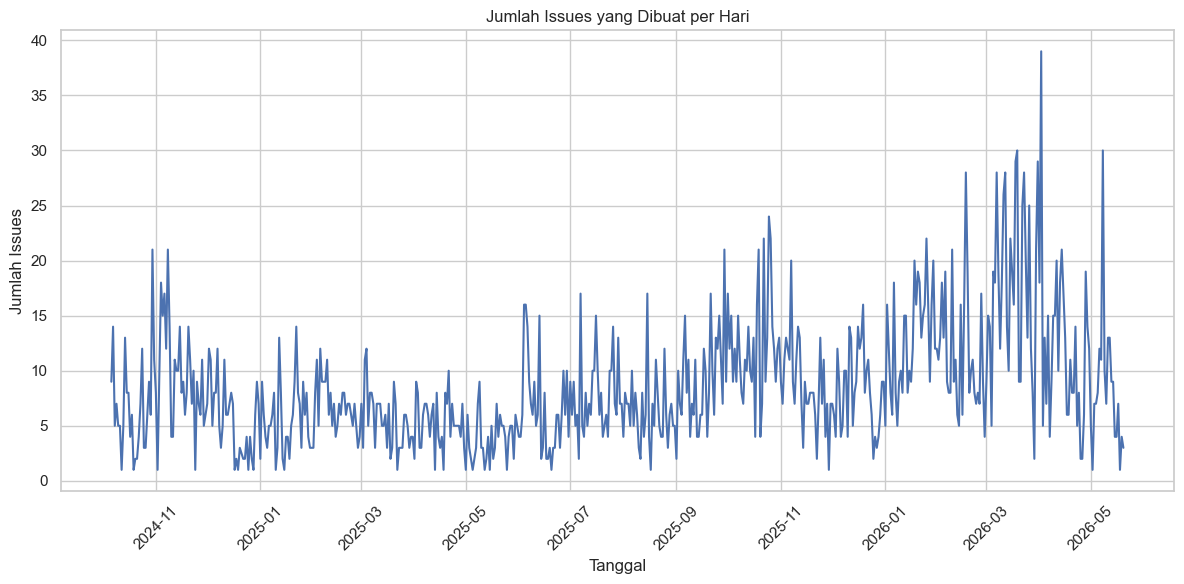

In [13]:
# Visualisasi Issues per Hari
issues_per_day = issues_clean.groupby(
    issues_clean["created_at"].dt.date
).size().reset_index()
issues_per_day.columns = ["date", "issues_count"]

plt.figure(figsize=(12, 6))
sns.lineplot(data=issues_per_day, x="date", y="issues_count")
plt.title("Jumlah Issues yang Dibuat per Hari")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Issues")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

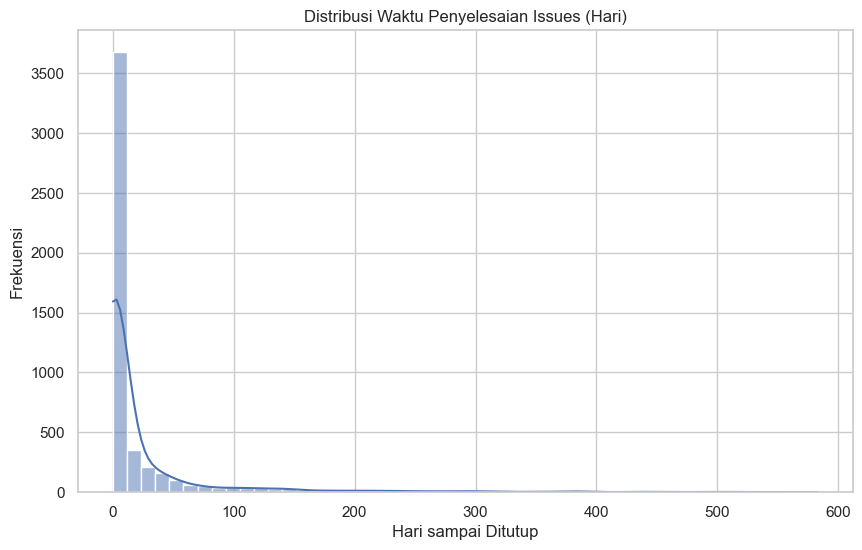

In [14]:
# Distribusi Waktu Penyelesaian (Close Time) untuk Issues
plt.figure(figsize=(10, 6))
sns.histplot(data=issues_clean, x="close_time_days", bins=50, kde=True)
plt.title("Distribusi Waktu Penyelesaian Issues (Hari)")
plt.xlabel("Hari sampai Ditutup")
plt.ylabel("Frekuensi")
plt.show()

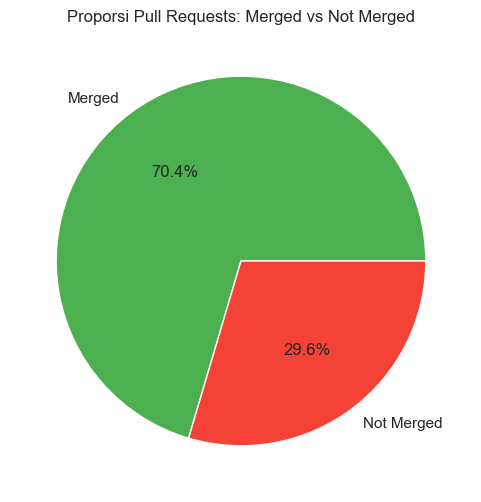

In [15]:
# Visualisasi Status PR (Merged vs Not Merged)
merged_counts = prs_clean["is_merged"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(merged_counts, labels=["Merged", "Not Merged"], autopct="%1.1f%%", colors=["#4CAF50", "#F44336"])
plt.title("Proporsi Pull Requests: Merged vs Not Merged")
plt.show()

## 5. Simpan ke Clean Data

In [16]:
print("Menyimpan data bersih...")

issues_clean.to_csv("../data/clean/issues_clean.csv", index=False)
prs_clean.to_csv("../data/clean/prs_clean.csv", index=False)
issues_per_day.to_csv("../data/clean/issues_per_day.csv", index=False)

print("✅ Selesai! File tersimpan di data/clean/")
print(f"\nRingkasan:")
print(f"- issues_clean.csv     : {len(issues_clean)} baris")
print(f"- prs_clean.csv        : {len(prs_clean)} baris")
print(f"- issues_per_day.csv   : {len(issues_per_day)} baris")

# Opsional: Jika ingin menggabungkan jadi dataset.csv untuk keperluan lain
# issues_clean.to_csv("../data/clean/dataset.csv", index=False)

Menyimpan data bersih...
✅ Selesai! File tersimpan di data/clean/

Ringkasan:
- issues_clean.csv     : 5000 baris
- prs_clean.csv        : 5001 baris
- issues_per_day.csv   : 586 baris
